## SDM274 Final Project

Check the requirements in `final_project.pdf`.

### Data Preprocessing

读取数据，共 210 条，每条数据有 6 个输入特征和 1 个标签。

注意数据文件中的分隔符是制表符，而不是逗号，需要指定 `sep='\t'`。

In [1]:
import warnings
warnings.filterwarnings('ignore', category = FutureWarning)

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

data_csv = pd.read_csv('seeds_dataset.txt', sep = '\t+', header = None)

data_csv.info()
data_csv.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       210 non-null    float64
 1   1       210 non-null    float64
 2   2       210 non-null    float64
 3   3       210 non-null    float64
 4   4       210 non-null    float64
 5   5       210 non-null    float64
 6   6       210 non-null    float64
 7   7       210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.2 KB


/tmp/ipykernel_78221/1495336136.py:9: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data_csv = pd.read_csv('seeds_dataset.txt', sep = '\t+', header = None)


,0,1,2,3,4,5,6,7
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


封装和划分数据集。

In [2]:
from simple_ml.data.dataset import *
from simple_ml.data.samples import *

dataset = Dataset(data = data_csv.to_numpy(), preprocess_func = label_split_for_single_output_dataset)
train_dataset, test_dataset = split_train_and_test_dataset(dataset, 0.2, seed = 2333)

print(len(train_dataset), len(test_dataset))

168 42


对数据进行归一化处理。

In [3]:
from sklearn.preprocessing import StandardScaler

scalar = StandardScaler()
train_dataset.datas[0] = scalar.fit_transform(train_dataset.datas[0])
test_dataset.datas[0] = scalar.transform(test_dataset.datas[0])

print(np.mean(train_dataset.datas[0], axis = 0), np.std(train_dataset.datas[0], axis = 0))

[ 1.16176909e-15  7.79799505e-16 -7.76792651e-15  7.29575130e-16
 -6.60847038e-18 -1.05880086e-16  2.39755306e-15] [1. 1. 1. 1. 1. 1. 1.]


### Tasks

按照文档要求实现各个任务。先导入相关组件：

In [13]:
from simple_ml.data.dimension import *
from simple_ml.model import *
from simple_ml.model.cluster import *
from simple_ml.model.ensemble import *
from simple_ml.model.layers import *
from simple_ml.training.loss import *
from simple_ml.training.optimizer import *
from simple_ml.evaluation.criterion import *

#### K-Means++

实现 K-Means++ 算法（详见 `simple_ml/model/cluster.py`，提交时单独取出，后同），并在数据集上测试。

In [5]:
model = KMeans(3, max_iteration = 1000, tolerance = 1e-6)

model.train(train_dataset)

pred_train = model.predict(train_dataset.datas[0])
pred_test = model.predict(test_dataset.datas[0])

accuracy_train = eval_multiclass_label_accuracy(pred_train, train_dataset.datas[1])
accuracy_test = eval_multiclass_label_accuracy(pred_test, test_dataset.datas[1])
print('Train Accuracy: {:.2f} %'.format(accuracy_train * 100))
print('Test Accuracy: {:.2f} %'.format(accuracy_test * 100))

Train Accuracy: 89.29 %
Test Accuracy: 90.48 %


将特征两两配对对聚类的结果进行可视化。其中红星为各重心位置，颜色为预测的类别，其中预测错误的样本用相应颜色的、透明的叉表示。

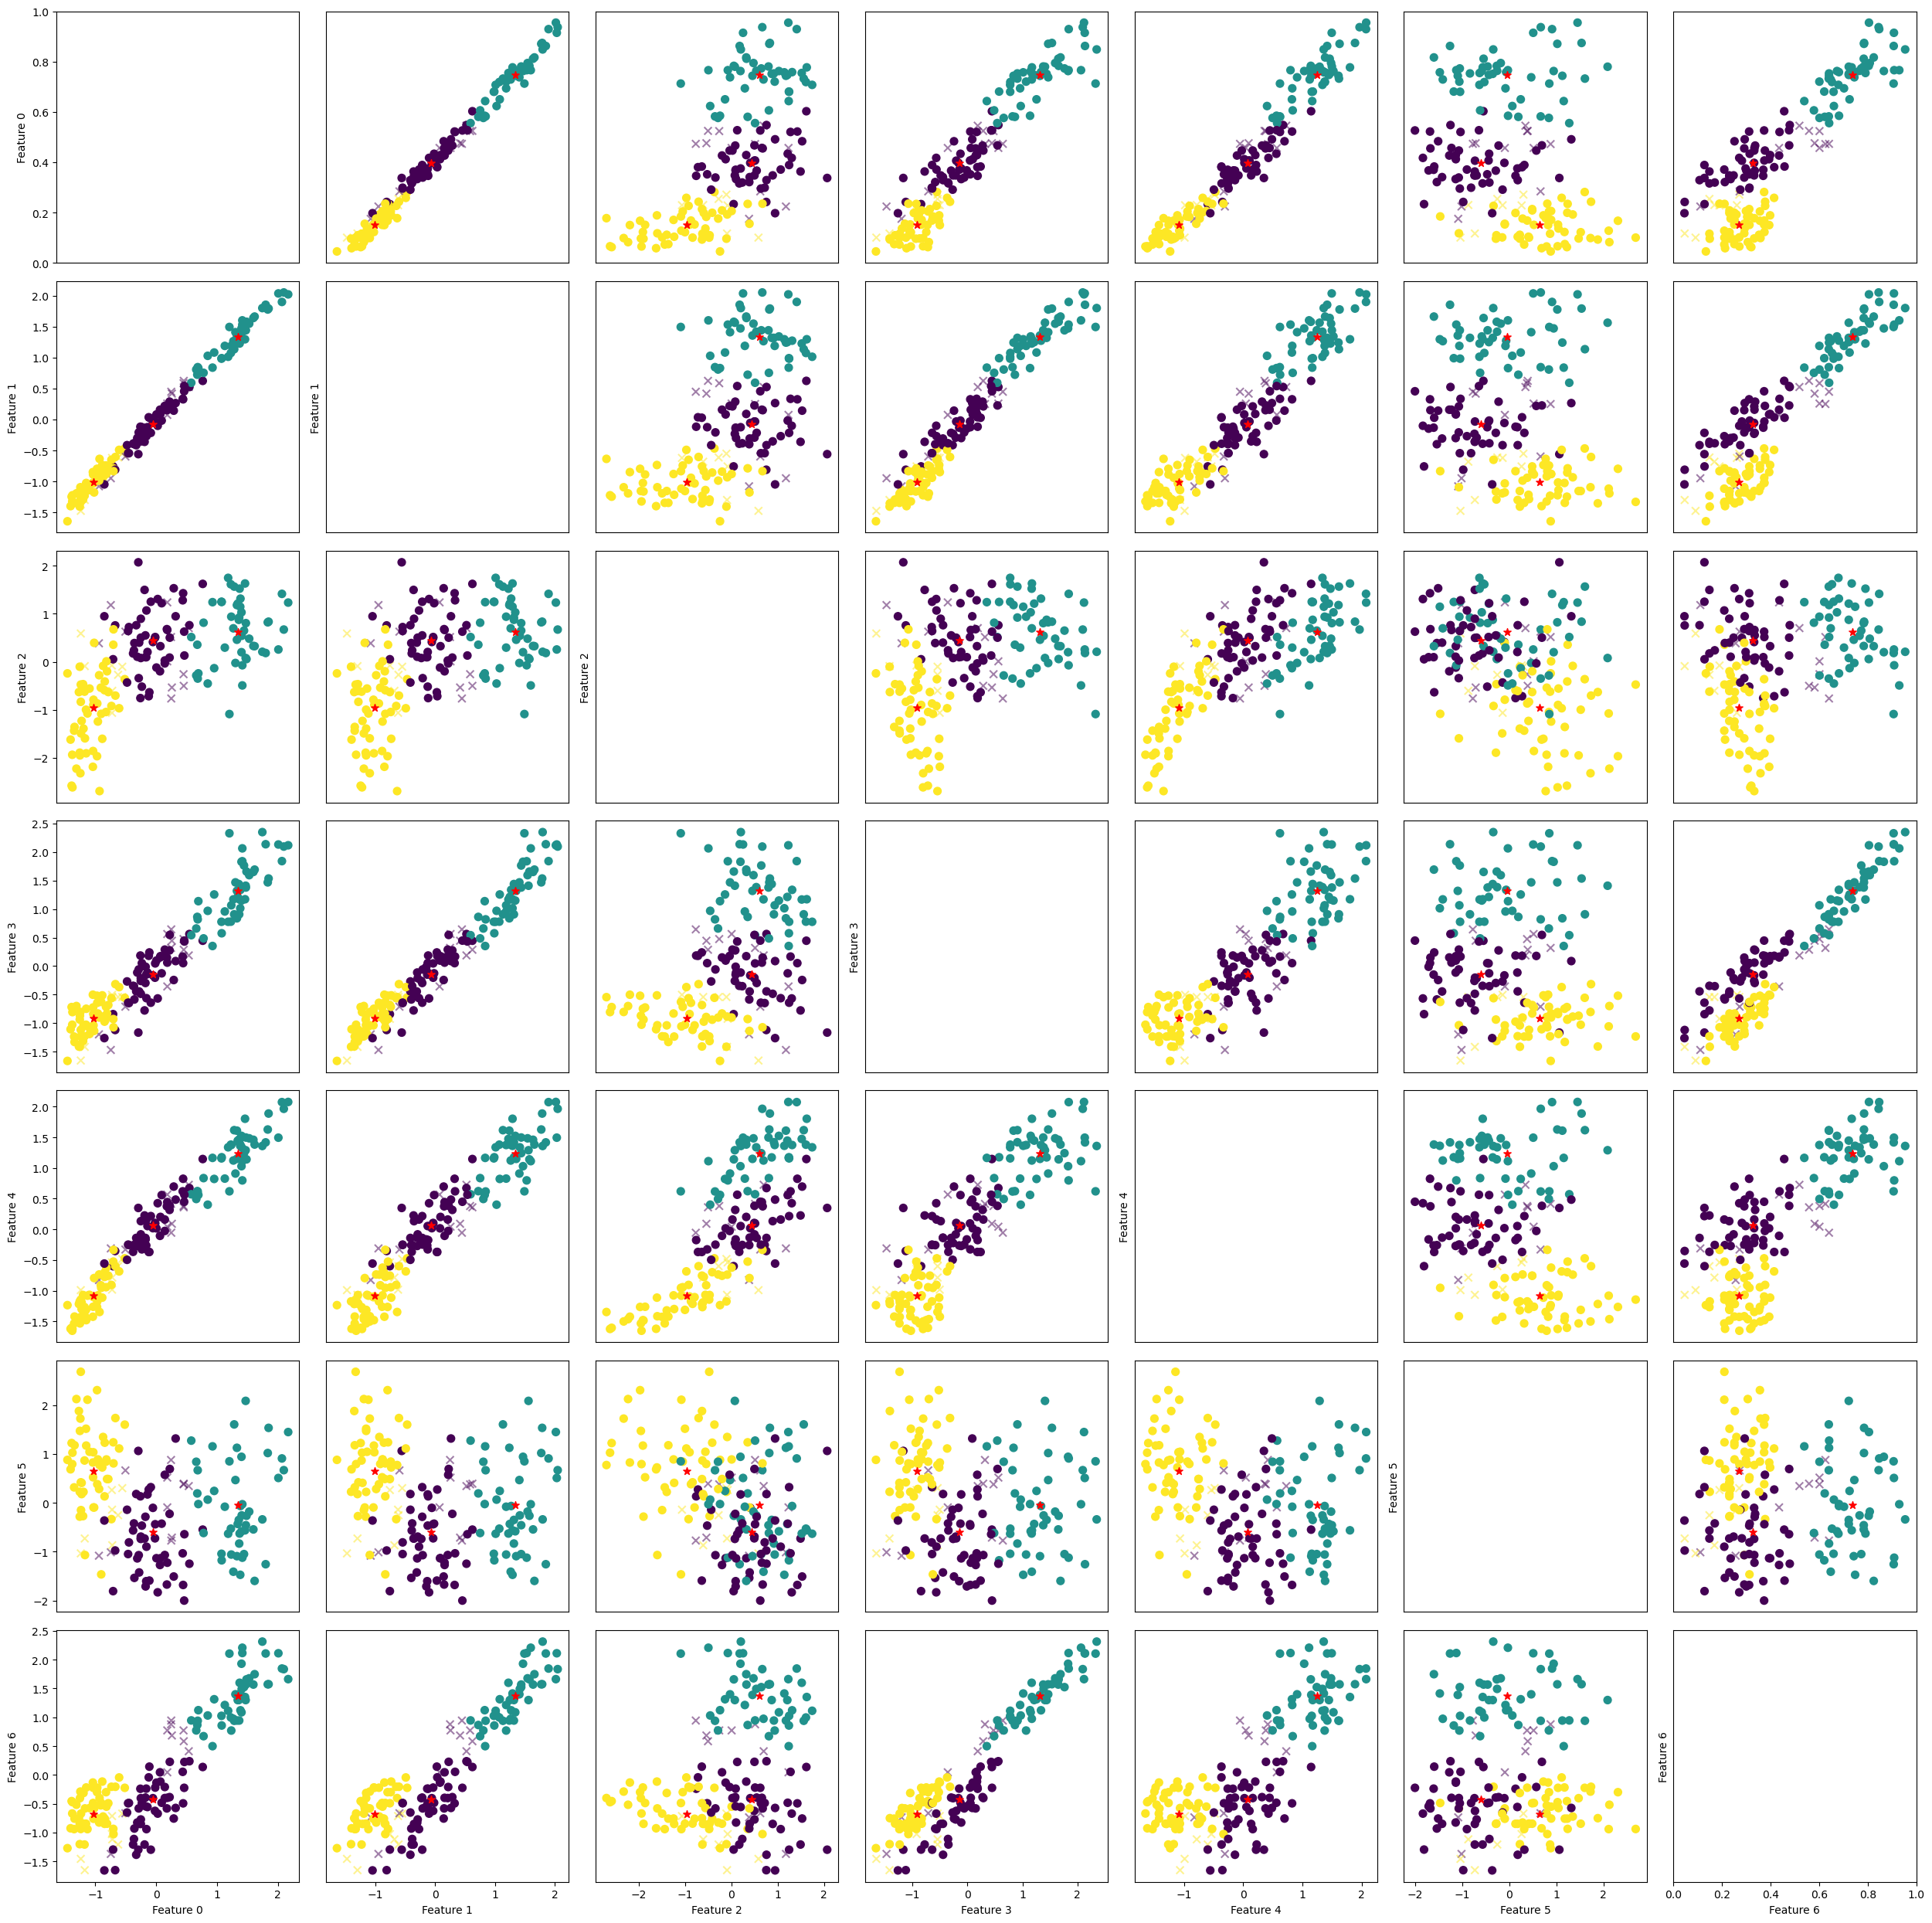

In [6]:
import itertools

def plot_cluster_pairplot(features, true_labels, pred_labels, centroids = None, figsize = (25, 25)):
    n_features = features.shape[1]
    fig, axes = plt.subplots(n_features, n_features, figsize=figsize)
    
    for i, j in itertools.product(range(n_features), repeat=2):
        ax = axes[i, j]
        if i == j:
            ax.set_ylabel(f'Feature {i}')
        else:
            match = np.array(true_labels == pred_labels)
            ax.scatter(features[~match, j], features[~match, i], c = pred_labels[~match], cmap = 'viridis', s = 50, alpha = 0.5, marker = 'x')
            ax.scatter(features[match, j], features[match, i], c = pred_labels[match], cmap = 'viridis', s = 50, alpha = 1, marker = 'o')
            if centroids is not None:
                ax.scatter(centroids[:, j], centroids[:, i], c = 'red', s = 50, marker = '*')

        if i == n_features - 1:
            ax.set_xlabel(f'Feature {j}')
        if j == 0:
            ax.set_ylabel(f'Feature {i}')
        if i != n_features - 1:
            ax.set_xticks([])
        if j != 0:
            ax.set_yticks([])

    plt.tight_layout()
    plt.show()

plot_cluster_pairplot(train_dataset.datas[0], train_dataset.datas[1].T[0].astype(int), pred_train, centroids = model.centroids)

#### Soft K-Means

实现 Soft K-Means 算法，并在数据集上测试。

In [7]:
model = SoftKMeans(3, max_iteration = 1000, tolerance = 1e-6, beta = 1)

model.train(train_dataset)

pred_train = model.predict(train_dataset.datas[0])
pred_test = model.predict(test_dataset.datas[0])

accuracy_train = eval_multiclass_label_accuracy(pred_train, train_dataset.datas[1])
accuracy_test = eval_multiclass_label_accuracy(pred_test, test_dataset.datas[1])

print('Train Accuracy: {:.2f} %'.format(accuracy_train * 100))
print('Test Accuracy: {:.2f} %'.format(accuracy_test * 100))

Train Accuracy: 89.88 %
Test Accuracy: 90.48 %


同样地，将特征两两配对对聚类的结果进行可视化。

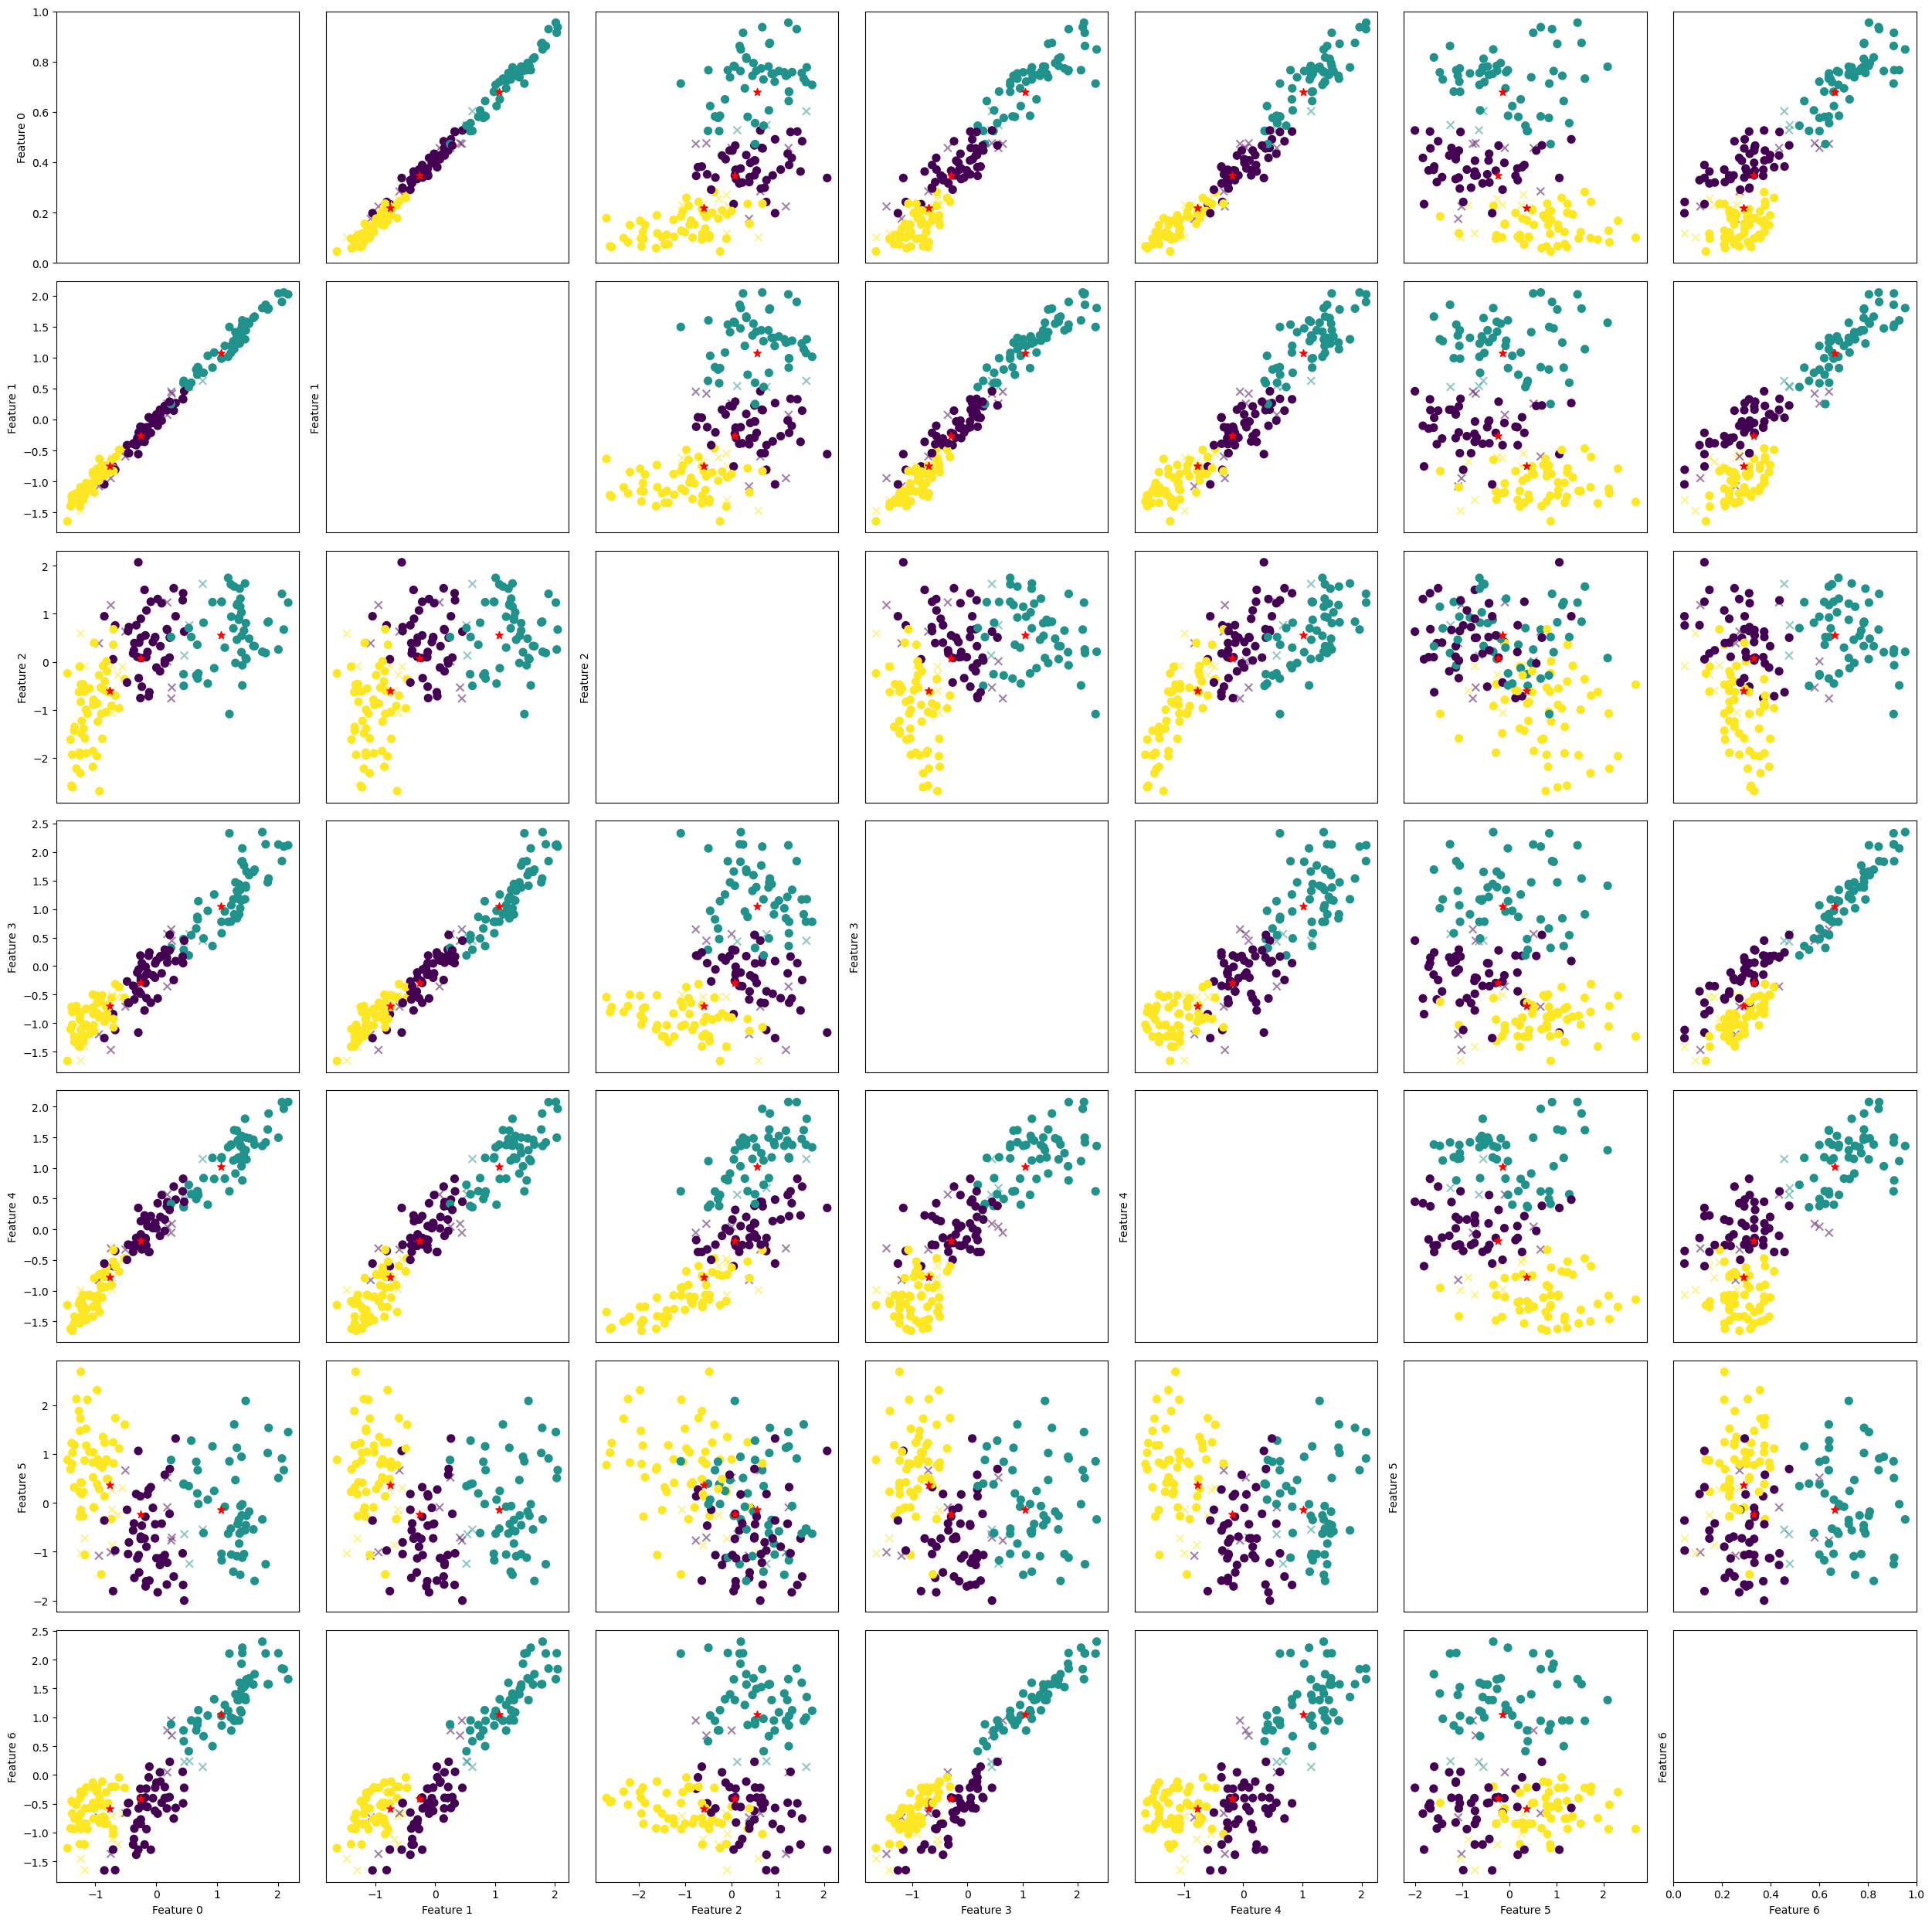

In [8]:
plot_cluster_pairplot(train_dataset.datas[0], train_dataset.datas[1].T[0].astype(int), pred_train, centroids = model.centroids)

#### PCA

实现 PCA 类，分别将数据降维到 2 维和 3 维，并可视化。

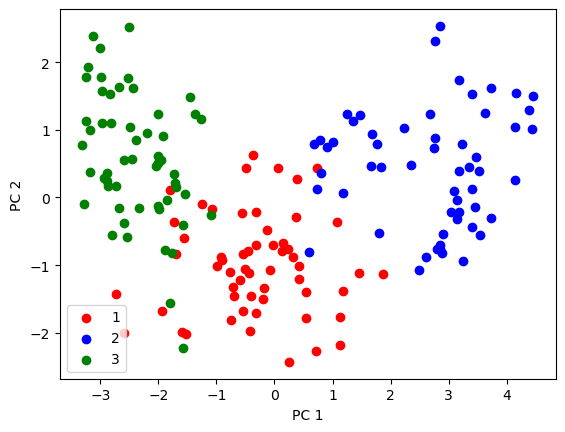

In [17]:
pca2d = PCA(2)
pca2d.train(train_dataset)
train_dataset_pca2d = pca2d.project(train_dataset)

# plot the training data on the two principal components
X_pca = train_dataset_pca2d.datas[0]
y = train_dataset_pca2d.datas[1].T[0].astype(int)

colors = ['r', 'b', 'g']
markers = ['o', 'o', 'o']

for l, c, m in zip(np.unique(y), colors, markers):
    plt.scatter(X_pca[y == l, 0], X_pca[y == l, 1], c = c, label = l, marker = m)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc = 'lower left')
plt.show()

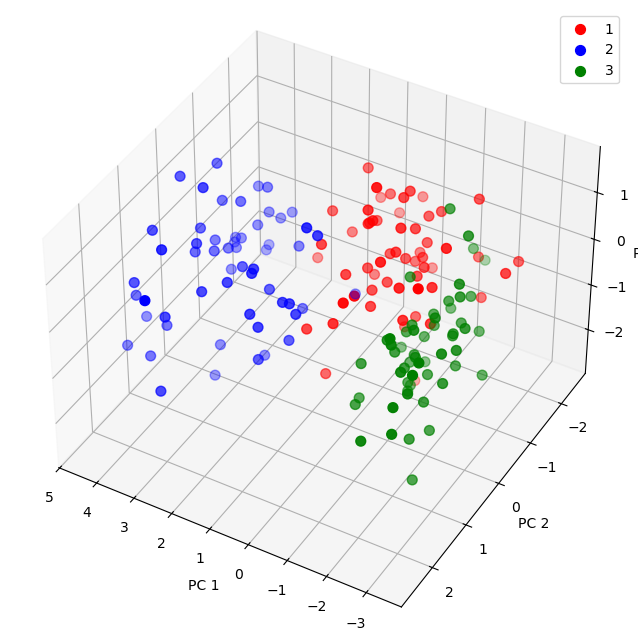

In [26]:
pca3d = PCA(3)
pca3d.train(train_dataset)
train_dataset_pca3d = pca3d.project(train_dataset)

# Extract the 3D PCA data
X_pca = train_dataset_pca3d.datas[0]
y = train_dataset_pca3d.datas[1].T[0].astype(int)

# Define colors and markers for the plot
colors = ['r', 'b', 'g']
markers = ['o', 'o', 'o']

# Create a 3D scatter plot with multiple viewpoints
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection = '3d')

for l, c, m in zip(np.unique(y), colors, markers):
    ax.scatter(
        X_pca[y == l, 0],
        X_pca[y == l, 1],
        X_pca[y == l, 2],
        c = c,
        label = l,
        marker = m,
        s = 50
    )

# Set axis labels
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')

# Add legend
ax.legend(loc = 'upper right')
ax.view_init(elev = 40, azim = 120)
plt.show()

#### Nonlinear Autoencoder

TODO

#### Clustering with Reduced Dimensions

TODO

#### MLP for Multi-Class Classification

TODO

#### SVM and SVM with Gaussian Kernel

TODO

#### AdaBoost

TODO

#### Binary Classification

TODO